In [ ]:
# Shared project setup for imports and file locations
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / 'data'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
FIGURES_DIR = PROJECT_ROOT / 'figures'

def resolve_path(path):
    candidate = Path(path)
    if candidate.exists():
        return candidate
    text = str(path).replace('\\', '/')
    name = Path(text).name
    special = {
        ARTIFACTS_DIR / 'controls' / 'positive_controls.pkl': ARTIFACTS_DIR / 'controls' / 'positive_controls.pkl',
        ARTIFACTS_DIR / 'controls' / 'negative_controls.pkl': ARTIFACTS_DIR / 'controls' / 'negative_controls.pkl',
        'Ten_positive_controls_1119.pkl': ARTIFACTS_DIR / 'controls' / 'positive_controls.pkl',
        'Ten_negative_controls_1119.pkl': ARTIFACTS_DIR / 'controls' / 'negative_controls.pkl',
        DATA_DIR / 'fcg.txt': DATA_DIR / 'fcg.txt',
    }
    if name in special:
        return special[name]
    matches = [p for p in PROJECT_ROOT.rglob(name) if '.ipynb_checkpoints' not in p.parts and '.git' not in p.parts]
    if len(matches) == 1:
        return matches[0]
    if (text.startswith('/Users/') or text.startswith('/home/') or ':\\' in text) and '.' not in name:
        return PROJECT_ROOT
    return candidate

from pdm_learn.preprocessing import build_density_map, density_centers, densitymap, drop_nan, extract, mut_trim, normalize, trim, trim_pairs
from pdm_learn.modeling import KFold_PR, LOOCV, LOOCV_grouped_plot, area_table, core_predict, heatmap, importance_test, ks_pvalue
from pdm_learn.simulation import eps, partition


In [1]:
import numpy as np
import pandas as pd
import json
from itertools import combinations
import itertools
import random
from collections import defaultdict
import os
import shutil
import ast
from matplotlib import pyplot as plt
import pickle
import json
import random
from collections import defaultdict
from itertools import combinations
from itertools import permutations
from itertools import product
import pickle
from scipy.stats import kendalltau
from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mutual_info_score
from statsmodels.stats.multitest import multipletests

In [2]:
os.chdir(PROJECT_ROOT)
os.getcwd()

'/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/Feb 11 update'

In [6]:
# Read in the dataframes
def DownloadAndRenaming(path):
    df = pd.read_csv(path)
    df = df.rename(columns={"Unnamed: 0": "Gene"})
    return df

cancer_complexes = pd.read_excel(resolve_path('/Users/guowanyi/Desktop/fall_2025/Louis_Vuitton/Nov24_update_required_files/cancer_complexes_clean.xlsx'), index_col = 0)
Gene_expression = DownloadAndRenaming(DATA_DIR / 'DepMap_Trimmed' / 'Gene_Expression_Trimmed.csv')
shRNA = DownloadAndRenaming(DATA_DIR / 'DepMap_Trimmed' / 'shRNA_Trimmed.csv')
CRISPR = DownloadAndRenaming(DATA_DIR / 'DepMap_Trimmed' / 'CRISPR_Trimmed.csv')
Gene_mutation = DownloadAndRenaming(DATA_DIR / 'DepMap_Trimmed' / 'Gene_Mutation_Trimmed.csv')
copy_number = DownloadAndRenaming(DATA_DIR / 'DepMap_Trimmed' / 'Copy_Number_Trimmed.csv')


cancer_complexes["Representative Genes (Core Members)"] = (cancer_complexes["Representative Genes (Core Members)"].apply(ast.literal_eval))

type(cancer_complexes["Representative Genes (Core Members)"].iloc[0])

list

In [7]:
Gene_mutation = Gene_mutation.rename(columns={"gene name": "Gene"})
Gene_mutation.columns

Index(['Gene', '127399_SOFT_TISSUE', '143B_BONE', '201T_LUNG',
       '22RV1_PROSTATE', '2313287_STOMACH', '253JBV_URINARY_TRACT',
       '253J_URINARY_TRACT', '42MGBA_CENTRAL_NERVOUS_SYSTEM', '451LU_SKIN',
       ...
       'YD15_SALIVARY_GLAND', 'YD38_UPPER_AERODIGESTIVE_TRACT',
       'YD8_UPPER_AERODIGESTIVE_TRACT', 'YH13_CENTRAL_NERVOUS_SYSTEM',
       'YKG1_CENTRAL_NERVOUS_SYSTEM', 'YMB1E_BREAST', 'YSCCC_BILIARY_TRACT',
       'YT_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE', 'ZR751_BREAST',
       'ZR7530_BREAST'],
      dtype='object', length=1742)

In [ ]:
# Read in the positive controls
with open(resolve_path('/Users/guowanyi/Desktop/fall_2025/Louis_Vuitton/Nov24_update_required_files/Ten_positive_controls_1119.pkl'), "rb") as f:
    Ten_positive_controls_1119 = pickle.load(f)

In [9]:
# Read in the negative controls
with open(resolve_path('/Users/guowanyi/Desktop/fall_2025/Louis_Vuitton/Nov24_update_required_files/Ten_negative_controls_1119.pkl'), "rb") as f:
    Ten_negative_controls_1119 = pickle.load(f)

Oki doki, let's write a function to compute the mutual information and bicor

In [10]:
# Convert the control dictionary to data frame
def convert2genePairDF(control_dict, controlType = ["positive", "negative"]):

    if isinstance(control_dict, pd.DataFrame):
        genePairDF = control_dict.copy()

    else: 

        if controlType == "negative":
            genePairDF = pd.DataFrame(control_dict, columns=["Gene1", "Gene2"])
        else:
            rows = []

            for complex_name, gene_pairs in control_dict.items():
                for g1, g2 in gene_pairs:
                    rows.append([g1, g2, complex_name])

            genePairDF = pd.DataFrame(rows, columns=["Gene1", "Gene2", "Complex"])

    
    return genePairDF

In [11]:
# For feature selection and following dependency calculations
def mutualInfo(genePairDF, featureMatrix1, featureMatrix2, nameOfMatrix1, nameOfMatrix2):
    # Keep the common cells
    commonSamples = list(featureMatrix1.columns.intersection(featureMatrix2.columns))


    copy1 = featureMatrix1[commonSamples]
    copy2 = featureMatrix2[commonSamples]
    numOfGenePairs = len(genePairDF)
    genesInCCLE = featureMatrix1['Gene'].tolist()


    #genePairFeatureValue = dict()
    MI_value = dict()     

    # Categorize those feature matrices
    data_type = {
        "CRISPR": "continuous",
        "Gene_expression": "continuous",
        "shRNA": "continuous",
        "copy_number": "discrete",
        "Gene_mutation": "binary"
    }

    # Get the type for inputted datasets
    data1Type = data_type[nameOfMatrix1]
    data2Type = data_type[nameOfMatrix2]
    dataTypes = (data1Type, data2Type)

    # Retrieve the gene pair
    
    for i in range(numOfGenePairs):
        gene1 = genePairDF.iloc[i]['Gene1']
        gene2 = genePairDF.iloc[i]['Gene2']
        #print("Retrieved gene1 and 2")
        # Retrieve the corresponding feature values
        #print(genePairDF.iloc[i])
        if gene1 in genesInCCLE and gene2 in genesInCCLE:


            gene1FeatureValue = copy1[copy1['Gene'] == gene1].iloc[:, 1:].values.flatten()
            gene2FeatureValue = copy2[copy2['Gene'] == gene2].iloc[:, 1:].values.flatten()
            x = gene1FeatureValue
            y = gene2FeatureValue

            mask = (~pd.isna(gene1FeatureValue)) & (~pd.isna(gene2FeatureValue))
            x = x[mask]
            y = y[mask]

            if dataTypes[0] == dataTypes[1] == "continuous":
                if len(x) < 20: # To ensure the reliability of the mutual information
                    MI_value[i] = np.nan
                    continue

                x = x.reshape(-1, 1)  
                mi = mutual_info_regression(x, y, random_state=0)[0]

            elif (dataTypes[0] == dataTypes[1] == "binary") or (dataTypes[0] == dataTypes[1] == "discrete"): 
                mi = mutual_info_score(x, y) 

            else:
                if dataTypes == ("continuous", "discrete"):
                    x_binned = pd.qcut(x, q=10, labels=False, duplicates="drop")
                    mi = mutual_info_score(x_binned, y)

                elif dataTypes == ("discrete", "continuous"):
                    y_binned = pd.qcut(y, q=10, labels=False, duplicates="drop")
                    mi = mutual_info_score(x, y_binned)

                elif dataTypes == ("binary", "discrete") or dataTypes == ("discrete", "binary"):
                    mi = mutual_info_score(x, y)

                elif dataTypes == ("continuous", "binary"):
                    x_binned = pd.qcut(x, q=10, labels=False, duplicates="drop")
                    mi = mutual_info_score(x_binned, y)

                elif dataTypes == ("binary", "continuous"):
                    y_binned = pd.qcut(y, q=10, labels=False, duplicates="drop")
                    mi = mutual_info_score(x, y_binned)

                else:
                        print("Your data types are invalid.")

            
            MI_value[i] = mi

    return MI_value
    


In [12]:
# Function to calculate correlations
def calculate_correlations(control, matrices, matrix_pairs, control_type = ["positive", "negative"]):
    correlations = {}

    for i, (feature_matrix1, feature_matrix2) in enumerate(matrix_pairs):
        print(f"Processing {i+1}/{len(matrix_pairs)}: {feature_matrix1} vs {feature_matrix2}")
        genePairDF = convert2genePairDF(control, control_type)
        
        correlation = mutualInfo(
            genePairDF,
            matrices[feature_matrix1],
            matrices[feature_matrix2],
            feature_matrix1,
            feature_matrix2
        )
        
        key = f"{feature_matrix1}_{feature_matrix2}"
        correlations[key] = correlation
        print(f"{i+1} has finished: {key}")

    return correlations

### Feature selection for MI

In [13]:
# Because there are ~5300 gene pairs in each negative controls
# We have to first match the sample size with the positive controls
def chooseNegatives_randomly(negative_control):
    #negDF = convert2genePairDF(negative_control, "negative")
    #random_neg = negDF.sample(70)
    negDF = random.sample(negative_control,70)

    return(negDF)

#chooseNegatives_randomly(Ten_negative_controls_1119["negative_controls_1"])
randomTenNegCtr = {
    key: chooseNegatives_randomly(neg_list)
    for key, neg_list in Ten_negative_controls_1119.items()
}

len(randomTenNegCtr["negative_controls_1"])

70

In [14]:
matrices = {
    'CRISPR' : CRISPR,
    'Gene_expression' : Gene_expression,
    'shRNA' : shRNA,
    "copy_number": copy_number,
    "Gene_mutation": Gene_mutation

}

matrixNames = list(matrices.keys())
matrix_pairs = list(product(matrixNames, repeat = 2))
print(matrix_pairs)

[('CRISPR', 'CRISPR'), ('CRISPR', 'Gene_expression'), ('CRISPR', 'shRNA'), ('CRISPR', 'copy_number'), ('CRISPR', 'Gene_mutation'), ('Gene_expression', 'CRISPR'), ('Gene_expression', 'Gene_expression'), ('Gene_expression', 'shRNA'), ('Gene_expression', 'copy_number'), ('Gene_expression', 'Gene_mutation'), ('shRNA', 'CRISPR'), ('shRNA', 'Gene_expression'), ('shRNA', 'shRNA'), ('shRNA', 'copy_number'), ('shRNA', 'Gene_mutation'), ('copy_number', 'CRISPR'), ('copy_number', 'Gene_expression'), ('copy_number', 'shRNA'), ('copy_number', 'copy_number'), ('copy_number', 'Gene_mutation'), ('Gene_mutation', 'CRISPR'), ('Gene_mutation', 'Gene_expression'), ('Gene_mutation', 'shRNA'), ('Gene_mutation', 'copy_number'), ('Gene_mutation', 'Gene_mutation')]


In [15]:
feature_pair_names = []

for pair in matrix_pairs:
    feature_name = f'{pair[0]}_{pair[1]}'
    feature_pair_names.append(feature_name)

feature_pair_names

['CRISPR_CRISPR',
 'CRISPR_Gene_expression',
 'CRISPR_shRNA',
 'CRISPR_copy_number',
 'CRISPR_Gene_mutation',
 'Gene_expression_CRISPR',
 'Gene_expression_Gene_expression',
 'Gene_expression_shRNA',
 'Gene_expression_copy_number',
 'Gene_expression_Gene_mutation',
 'shRNA_CRISPR',
 'shRNA_Gene_expression',
 'shRNA_shRNA',
 'shRNA_copy_number',
 'shRNA_Gene_mutation',
 'copy_number_CRISPR',
 'copy_number_Gene_expression',
 'copy_number_shRNA',
 'copy_number_copy_number',
 'copy_number_Gene_mutation',
 'Gene_mutation_CRISPR',
 'Gene_mutation_Gene_expression',
 'Gene_mutation_shRNA',
 'Gene_mutation_copy_number',
 'Gene_mutation_Gene_mutation']

In [16]:
# Function for comparing the medians across ten positive and negative controls with Mann-Whiteney U test
def SummarizeDependencies_1(all_controls, matrices, matrix_pairs, control_type):
    MI_summary = dict()
    for control in all_controls.keys():
        #print(control)
        this_ctrl = all_controls[control]
        this_MI_dependency = calculate_correlations(this_ctrl, matrices, matrix_pairs, control_type)
        MI_summary[control] = this_MI_dependency

    return MI_summary

def SummarizeDependencies_2(MI_summary):

    MI_median_summary = dict()

    for condition, interaction_dict in MI_summary.items():
        MI_median_summary[condition] = {}
        for interaction_type, index_dict in interaction_dict.items():
            values = list(index_dict.values())
            MI_median_summary[condition][interaction_type] = np.nanmedian(values)

    return MI_median_summary 


def SummarizeDependencies_3(pos_median_summary, neg_median_summary, feature_pair_names):
    positive_everyComb_dataPoints = {}
    negative_everyComb_dataPoints = {}

    for everyComb in feature_pair_names:
        positive_everyComb_dataPoints[everyComb] = []
        negative_everyComb_dataPoints[everyComb] = []
        for i in range(10):
            thisComb_pos = pos_median_summary[f'positive_control_{i+1}'][everyComb]
            thisComb_neg = neg_median_summary[f'negative_controls_{i+1}'][everyComb]
            positive_everyComb_dataPoints[everyComb].append(thisComb_pos)
            negative_everyComb_dataPoints[everyComb].append(thisComb_neg)

    return positive_everyComb_dataPoints, negative_everyComb_dataPoints # The output should be the median for every feature (each feature should have 10 data points)


def AssessSignificance(positive_everyComb_dataPoints, negative_everyComb_dataPoints, feature_pair_names):
    significance_results = {}

    for comb in feature_pair_names:
        pos_vals = positive_everyComb_dataPoints[comb]
        neg_vals = negative_everyComb_dataPoints[comb]
        stat, p = mannwhitneyu(pos_vals, neg_vals, alternative="two-sided")
        significance_results[comb] = (stat, p)

    return significance_results 


In [17]:
# summarize into one complete function

def featureSignificance(positive_all_controls, negative_all_controls, matrices, matrix_pairs, feature_pair_names):
    # First, calculate the dependency between all gene pairs across ten controls with MI
    all_pos_MI_summary = SummarizeDependencies_1(positive_all_controls, matrices, matrix_pairs, "positive")
    all_neg_MI_summary = SummarizeDependencies_1(negative_all_controls, matrices, matrix_pairs, "negative")
    # Next, condense the ~70 gene pairs to one median for each control trial
    pos_median_summary = SummarizeDependencies_2(all_pos_MI_summary)
    neg_median_summary = SummarizeDependencies_2(all_neg_MI_summary)
    pos_everyComb_dps, neg_everyComb_dps = SummarizeDependencies_3(pos_median_summary, neg_median_summary, feature_pair_names)

    # Evaluate the significance between every feature combination
    feature_significance_results = AssessSignificance(pos_everyComb_dps, neg_everyComb_dps, feature_pair_names)

    return feature_significance_results



In [18]:
MI_feature_significance_results = featureSignificance(Ten_positive_controls_1119, randomTenNegCtr, matrices, matrix_pairs, feature_pair_names)
MI_feature_significance_results

Processing 1/25: CRISPR vs CRISPR
1 has finished: CRISPR_CRISPR
Processing 2/25: CRISPR vs Gene_expression
2 has finished: CRISPR_Gene_expression
Processing 3/25: CRISPR vs shRNA
3 has finished: CRISPR_shRNA
Processing 4/25: CRISPR vs copy_number
4 has finished: CRISPR_copy_number
Processing 5/25: CRISPR vs Gene_mutation
5 has finished: CRISPR_Gene_mutation
Processing 6/25: Gene_expression vs CRISPR
6 has finished: Gene_expression_CRISPR
Processing 7/25: Gene_expression vs Gene_expression
7 has finished: Gene_expression_Gene_expression
Processing 8/25: Gene_expression vs shRNA
8 has finished: Gene_expression_shRNA
Processing 9/25: Gene_expression vs copy_number
9 has finished: Gene_expression_copy_number
Processing 10/25: Gene_expression vs Gene_mutation
10 has finished: Gene_expression_Gene_mutation
Processing 11/25: shRNA vs CRISPR
11 has finished: shRNA_CRISPR
Processing 12/25: shRNA vs Gene_expression
12 has finished: shRNA_Gene_expression
Processing 13/25: shRNA vs shRNA
13 has fi

{'CRISPR_CRISPR': (100.0, 0.00018267179110955002),
 'CRISPR_Gene_expression': (74.0, 0.06254128696758936),
 'CRISPR_shRNA': (64.0, 0.3010413975231693),
 'CRISPR_copy_number': (83.0, 0.014019277113959953),
 'CRISPR_Gene_mutation': (77.0, 0.04515456962427901),
 'Gene_expression_CRISPR': (84.0, 0.01120695479765041),
 'Gene_expression_Gene_expression': (100.0, 0.00018267179110955002),
 'Gene_expression_shRNA': (61.5, 0.3994053617881699),
 'Gene_expression_copy_number': (96.0, 0.0005828399431792743),
 'Gene_expression_Gene_mutation': (95.0, 0.0007685389131627665),
 'shRNA_CRISPR': (91.5, 0.0016842263105423972),
 'shRNA_Gene_expression': (90.0, 0.0028169056281937455),
 'shRNA_shRNA': (91.0, 0.0022022199424970783),
 'shRNA_copy_number': (38.0, 0.3846730627355087),
 'shRNA_Gene_mutation': (0.0, 0.00018267179110955002),
 'copy_number_CRISPR': (99.0, 0.00024612812790522973),
 'copy_number_Gene_expression': (100.0, 0.00018267179110955002),
 'copy_number_shRNA': (32.0, 0.18587673236587576),
 'copy

In [19]:
# Use a data frame to summarize the significance
MI_feature_significance_df = pd.DataFrame(MI_feature_significance_results)
MI_feature_significance_df.index = ["U-statistics", "p-val"]
MI_feature_significance_df = MI_feature_significance_df.T
MI_feature_significance_df

,U-statistics,p-val
CRISPR_CRISPR,100.0,0.000183
CRISPR_Gene_expression,74.0,0.062541
CRISPR_shRNA,64.0,0.301041
CRISPR_copy_number,83.0,0.014019
CRISPR_Gene_mutation,77.0,0.045155
Gene_expression_CRISPR,84.0,0.011207
Gene_expression_Gene_expression,100.0,0.000183
Gene_expression_shRNA,61.5,0.399405
Gene_expression_copy_number,96.0,0.000583
Gene_expression_Gene_mutation,95.0,0.000769


In [20]:
# We need to do FDR adjustment for 25 independent testings
MI_feature_significance_df["adj_p-val"] = multipletests(MI_feature_significance_df["p-val"], method="fdr_bh")[1]
MI_feature_significance_df

,U-statistics,p-val,adj_p-val
CRISPR_CRISPR,100.0,0.000183,0.000913
CRISPR_Gene_expression,74.0,0.062541,0.082291
CRISPR_shRNA,64.0,0.301041,0.342092
CRISPR_copy_number,83.0,0.014019,0.021905
CRISPR_Gene_mutation,77.0,0.045155,0.062715
Gene_expression_CRISPR,84.0,0.011207,0.020012
Gene_expression_Gene_expression,100.0,0.000183,0.000913
Gene_expression_shRNA,61.5,0.399405,0.416047
Gene_expression_copy_number,96.0,0.000583,0.001821
Gene_expression_Gene_mutation,95.0,0.000769,0.002135


In [21]:
MI_feature_significance_df.to_csv(ARTIFACTS_DIR / 'results' / ARTIFACTS_DIR / 'results' / ARTIFACTS_DIR / 'results' / 'MI_feature_sig_df_0211.csv', index = True)

#### Plot the significance for MI features with a 5*5 heatmap

In [22]:
MI_feature_significance_df = pd.read_csv(ARTIFACTS_DIR / 'results' / ARTIFACTS_DIR / 'results' / ARTIFACTS_DIR / 'results' / 'MI_feature_sig_df_0211.csv')
MI_feature_significance_df.head()

,Unnamed: 0,U-statistics,p-val,adj_p-val
0,CRISPR_CRISPR,100.0,0.000183,0.000913
1,CRISPR_Gene_expression,74.0,0.062541,0.082291
2,CRISPR_shRNA,64.0,0.301041,0.342092
3,CRISPR_copy_number,83.0,0.014019,0.021905
4,CRISPR_Gene_mutation,77.0,0.045155,0.062715


In [29]:
MI_feature_significance_df = MI_feature_significance_df.rename({"Unnamed: 0":"Features"})
MI_feature_significance_df.head()

,Unnamed: 0,U-statistics,p-val,adj_p-val
0,CRISPR_CRISPR,100.0,0.000183,0.000913
1,CRISPR_Gene_expression,74.0,0.062541,0.082291
2,CRISPR_shRNA,64.0,0.301041,0.342092
3,CRISPR_copy_number,83.0,0.014019,0.021905
4,CRISPR_Gene_mutation,77.0,0.045155,0.062715


In [32]:
datasets = ["CRISPR", "Gene_expression", "shRNA", "copy_number", "Gene_mutation"]

def split_feature(x):
    for d in datasets:
        if x.startswith(d + "_"):
            return pd.Series([d, x[len(d)+1:]])
    return pd.Series([None, None])

MI_feature_significance_df[['Dataset1', 'Dataset2']] = MI_feature_significance_df['Unnamed: 0'].apply(split_feature)
MI_feature_significance_df


,Unnamed: 0,U-statistics,p-val,adj_p-val,Dataset1,Dataset2
0,CRISPR_CRISPR,100.0,0.000183,0.000913,CRISPR,CRISPR
1,CRISPR_Gene_expression,74.0,0.062541,0.082291,CRISPR,Gene_expression
2,CRISPR_shRNA,64.0,0.301041,0.342092,CRISPR,shRNA
3,CRISPR_copy_number,83.0,0.014019,0.021905,CRISPR,copy_number
4,CRISPR_Gene_mutation,77.0,0.045155,0.062715,CRISPR,Gene_mutation
5,Gene_expression_CRISPR,84.0,0.011207,0.020012,Gene_expression,CRISPR
6,Gene_expression_Gene_expression,100.0,0.000183,0.000913,Gene_expression,Gene_expression
7,Gene_expression_shRNA,61.5,0.399405,0.416047,Gene_expression,shRNA
8,Gene_expression_copy_number,96.0,0.000583,0.001821,Gene_expression,copy_number
9,Gene_expression_Gene_mutation,95.0,0.000769,0.002135,Gene_expression,Gene_mutation


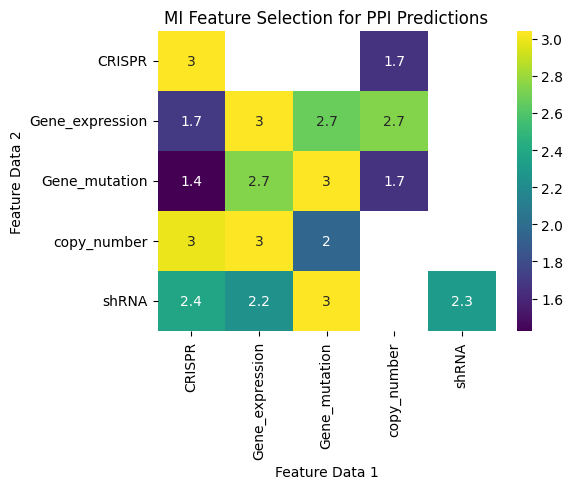

In [38]:
heatmap_df = MI_feature_significance_df.pivot(index='Dataset1',
                      columns='Dataset2',
                      values='adj_p-val')

heatmap_values = -np.log10(heatmap_df)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
threshold = heatmap_df > 0.05
sns.heatmap(heatmap_values,
            annot=True,
            cmap='viridis',
            mask=threshold)

plt.title("MI Feature Selection for PPI Predictions")
plt.xlabel("Feature Data 1")
plt.ylabel("Feature Data 2")
plt.tight_layout()
plt.savefig("MI Feature Selection for PPI Predictions.png", dpi = 300)
plt.show()

